In [1]:
import pandas as pd

pd.set_option('display.float_format', '{:,.2f}'.format)




In [3]:
df = pd.read_csv("vendas_supermercado_com_cliente.csv")
df['Data'] = pd.to_datetime(df['Data'])
df.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.00,164.60,49,"2,715.61"
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.00,9.56,29,"2,280.15"
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.00,41.90,67,"4,419.56"
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.00,30.45,29,"3,809.17"
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.00,519.96,24,"1,013.42"


In [4]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data         20075 non-null  datetime64[ns]
 1   Produto      20075 non-null  object        
 2   Categoria    20075 non-null  object        
 3   Preço        20075 non-null  float64       
 4   Quantidade   20075 non-null  int64         
 5   Desconto     20075 non-null  float64       
 6   Total_Venda  20075 non-null  float64       
 7   Idade        20075 non-null  int64         
 8   Renda        20075 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 1.4+ MB


In [5]:
df.describe()

,Data,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075,"20,075.00","20,075.00","20,075.00","20,075.00","20,075.00","20,075.00"
mean,2023-07-02 00:00:00,25.58,10.01,0.04,245.90,45.99,"2,999.03"
min,2023-01-01 00:00:00,1.00,1.00,0.00,0.91,18.00,"1,000.38"
25%,2023-04-02 00:00:00,13.26,5.00,0.00,75.60,32.00,"1,993.62"
50%,2023-07-02 00:00:00,25.66,10.00,0.00,186.32,46.00,"2,998.83"
75%,2023-10-01 00:00:00,37.77,15.00,0.00,370.04,60.00,"4,007.68"
max,2023-12-31 00:00:00,49.99,19.00,0.50,949.05,74.00,"4,999.76"
std,NaN,14.12,5.49,0.09,207.77,16.48,"1,159.72"


## ESTATÍSTICA DESCRITIVA

### Medidas de tendência central: 

In [6]:
variaveis = ['Preço', 'Quantidade', 'Desconto', 'Total_Venda', 'Idade', 'Renda']

estatisticas = {}

for var in variaveis:
    estatisticas[var] = {
        'Média': df[var].mean(),
        'Mediana': df[var].median(),
        'Moda': df[var].mode()[0] if not df[var].mode().empty else None,
        'Desvio-Padrão': df[var].std(),
        'Variância': df[var].var(),
        'Amplitude': df[var].max() - df[var].min(),
        'Coeficiente de Variação (%)': (df[var].std() / df[var].mean()) * 100
    }

estatisticas_df = pd.DataFrame(estatisticas).T
estatisticas_df


,Média,Mediana,Moda,Desvio-Padrão,Variância,Amplitude,Coeficiente de Variação (%)
Preço,25.58,25.66,10.58,14.12,199.26,48.99,55.19
Quantidade,10.01,10.00,6.00,5.49,30.12,18.00,54.84
Desconto,0.04,0.00,0.00,0.09,0.01,0.50,213.81
Total_Venda,245.90,186.32,50.04,207.77,"43,169.91",948.14,84.49
Idade,45.99,46.00,52.00,16.48,271.66,56.00,35.84
Renda,"2,999.03","2,998.83","1,630.87","1,159.72","1,344,944.39","3,999.38",38.67


### Medidas separatrizes

In [7]:
variaveis = ['Preço', 'Quantidade', 'Desconto', 'Total_Venda', 'Idade', 'Renda']

quartis = df[variaveis].quantile([0.25, 0.5, 0.75])
percentis = df[variaveis].quantile([0.01, 0.10, 0.50, 0.90, 0.99])

quartis, percentis

(      Preço  Quantidade  Desconto  Total_Venda  Idade    Renda
 0.25  13.26        5.00      0.00        75.60  32.00 1,993.62
 0.50  25.66       10.00      0.00       186.32  46.00 2,998.83
 0.75  37.77       15.00      0.00       370.04  60.00 4,007.68,
       Preço  Quantidade  Desconto  Total_Venda  Idade    Renda
 0.01   1.52        1.00      0.00         6.38  18.00 1,039.99
 0.10   6.02        2.00      0.00        30.50  23.00 1,390.84
 0.50  25.66       10.00      0.00       186.32  46.00 2,998.83
 0.90  45.04       18.00      0.19       562.69  69.00 4,601.30
 0.99  49.54       19.00      0.33       834.54  74.00 4,957.96)

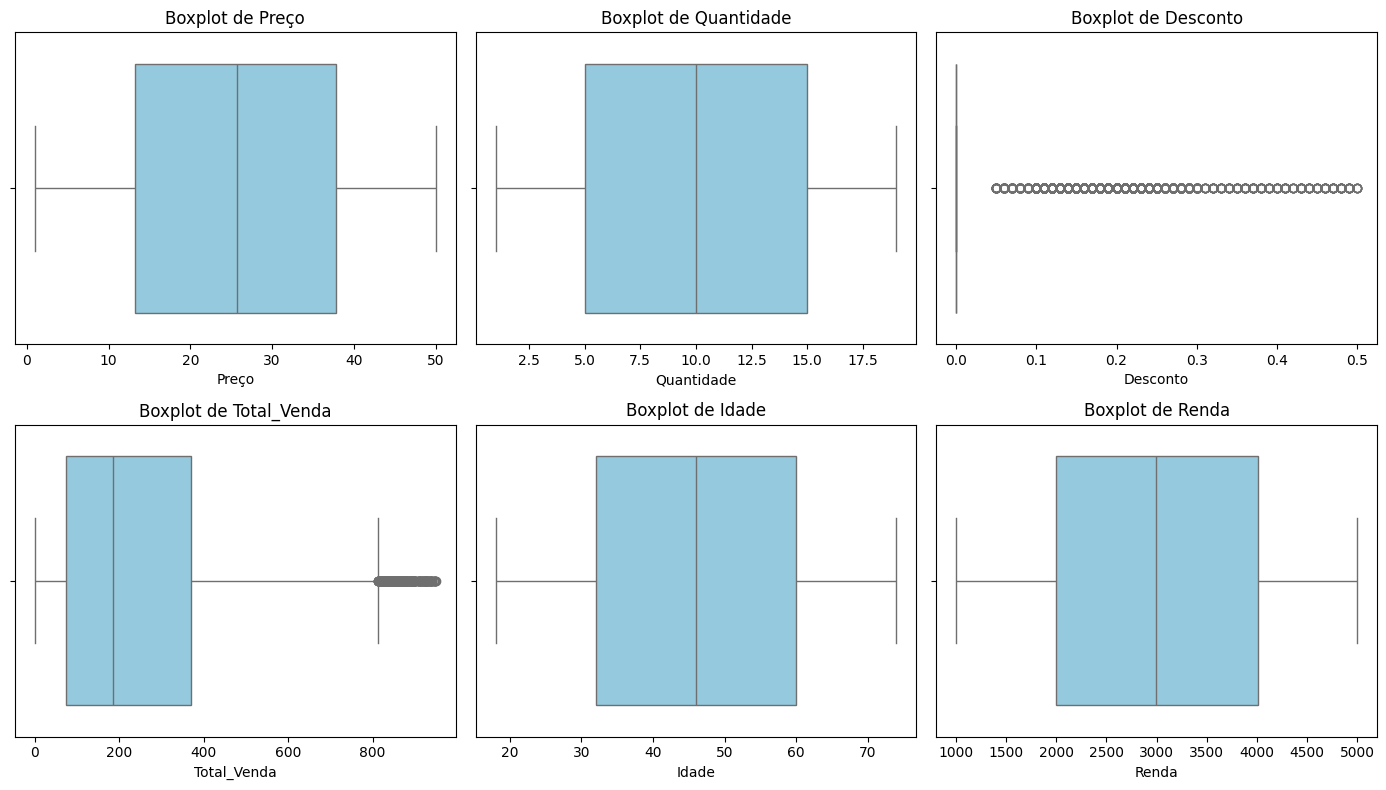

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

variaveis = ['Preço', 'Quantidade', 'Desconto', 'Total_Venda', 'Idade', 'Renda']

plt.figure(figsize=(14, 8))

for i, var in enumerate(variaveis, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[var], color='skyblue')
    plt.title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()



#### 1. Boxplot de Preço
A distribuição do preço é bem concentrada, sem valores extremos.

Não há outliers — todos os preços estão dentro dos limites do IQR.

Isso indica que os produtos têm preços consistentes, sem grandes variações.

#### 2. Boxplot de Quantidade
A quantidade vendida também é estável, variando entre 0 e 18.

Não há outliers — o comportamento de compra por quantidade é regular.

Isso mostra que os clientes compram quantidades previsíveis, sem compras exageradas.

#### 3. Boxplot de Desconto
Aqui vemos vários pontos fora da caixa, ou seja, outliers.

A distribuição é mais espalhada, com descontos que vão até 0.5 (50%).

Esses outliers representam: promoções especiais (Black Friday e campanhas),

ou erros de cadastro (descontos muito altos ou inconsistentes).

#### 4. Boxplot de Total_Venda
A maior parte das vendas está entre 150 e 350 reais.

Existem outliers acima de 800 reais, indicando compras muito grandes.

Esses outliers são comportamento real, não erro — representam compras de alto valor.

#### 5. Boxplot de Idade
A idade varia entre aproximadamente 20 e 70 anos.

Não há outliers — todas as idades estão dentro do intervalo esperado.

Isso indica que a base não tem idades inválidas (ex.: 5 anos, 120 anos).

#### 6. Boxplot de Renda
A renda varia entre 1000 e 5000 reais.

A distribuição é relativamente simétrica.

Não há outliers — todas as rendas estão dentro do padrão esperado.

Isso mostra que a base não tem valores absurdos.

Conclusão: Apesar de algumas variáveis apresentarem outliers, todos estão dentro do esperado e devem ser mantidos

### Análise da forma da distribuição

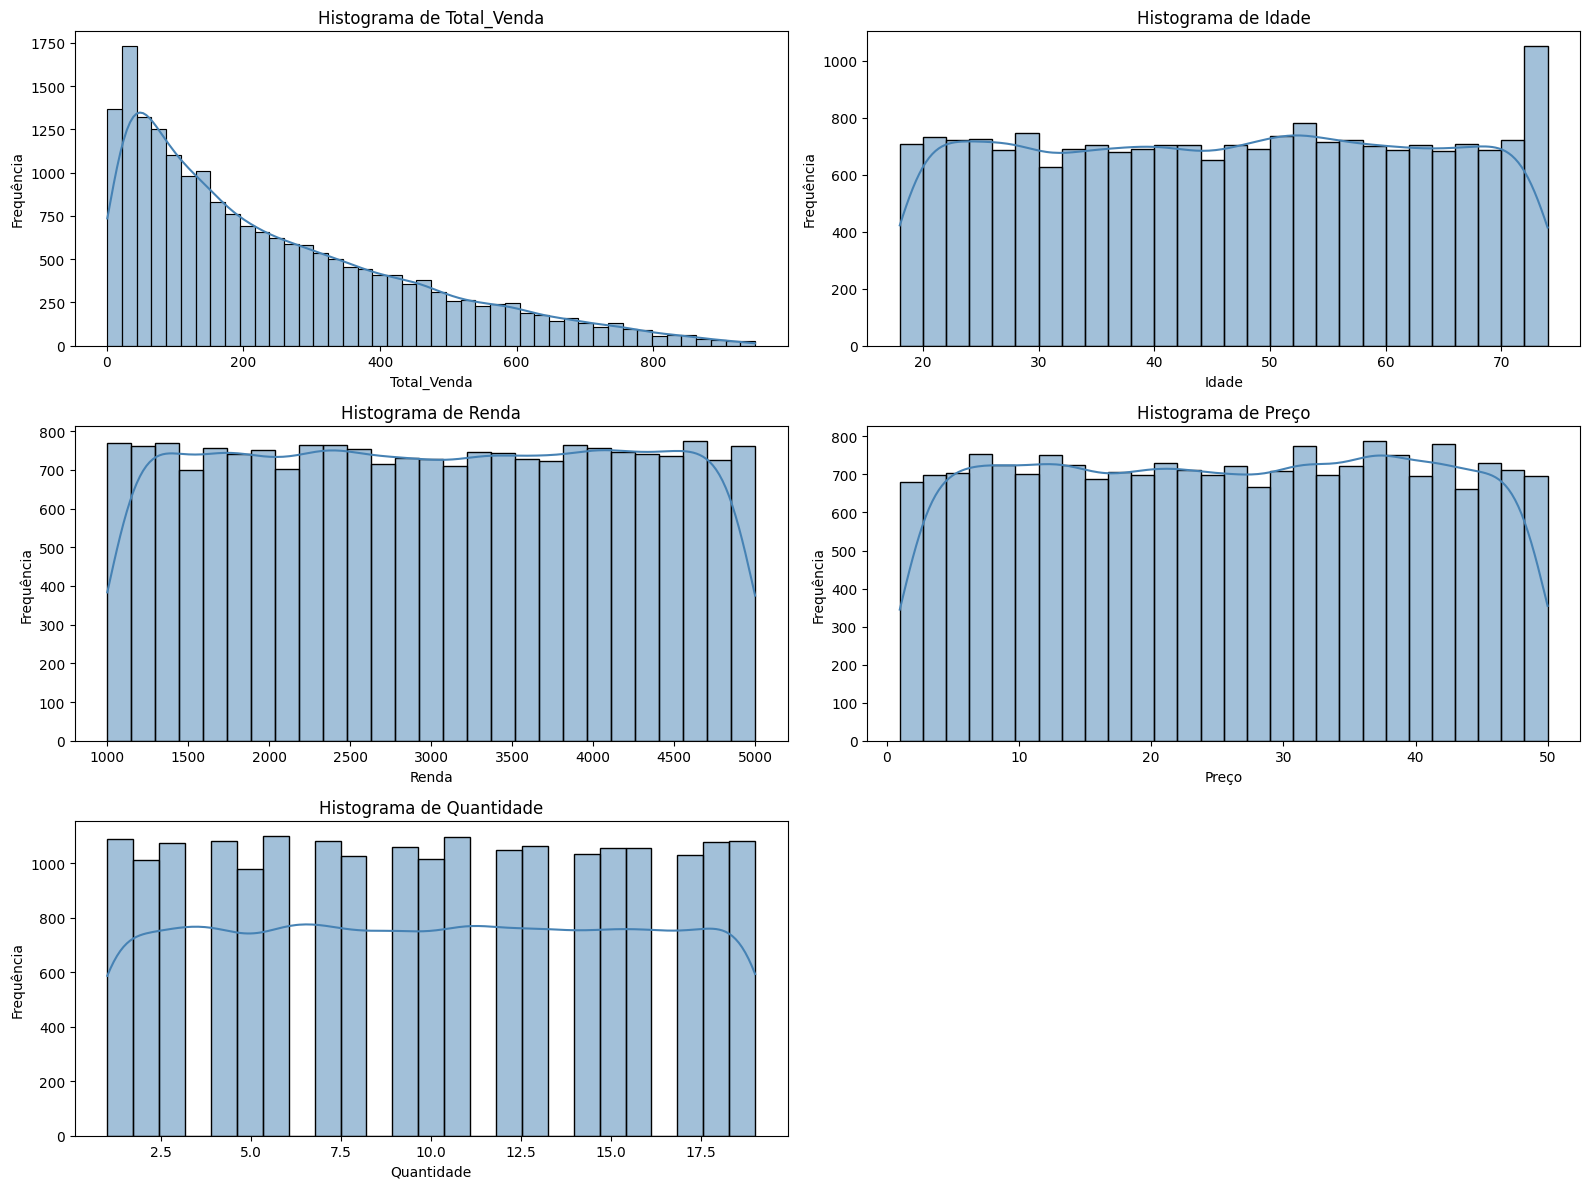

In [9]:


variaveis = ['Total_Venda', 'Idade', 'Renda', 'Preço', 'Quantidade']

plt.figure(figsize=(16, 12))

for i, var in enumerate(variaveis, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[var], kde=True, color='steelblue')
    plt.title(f'Histograma de {var}')
    plt.xlabel(var)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()


 #### 1. Histograma de Total_Venda

A distribuição é fortemente assimétrica à direita.

A maior parte das vendas está concentrada em valores baixos e médios.

A cauda longa mostra a presença de vendas de alto valor.

Conclusão:
Compras grandes são raras, mas existem.

A distribuição não é normal —  muitos valores pequenos e poucos valores altos.

#### 2. Histograma de Idade

A distribuição é relativamente uniforme, com leve concentração entre 30 e 55 anos.

Não há caudas longas nem picos exagerados.

A idade dos clientes é bem distribuída.

A forma é quase simétrica, aproximando-se de uma distribuição normal.


#### 3. Histograma de Renda

A renda aparece distribuída de forma quase uniforme entre 1000 e 5000.

Não há concentração forte em nenhum ponto específico.

A curva é relativamente plana.

A renda não segue uma distribuição normal.


#### 4. Histograma de Preço

Os preços estão distribuídos de forma quase uniforme entre 0 e 50.

Não há cauda longa nem concentração forte.

A distribuição não é normal.

Os preços dos produtos são variados, sem picos ou extremos.

#### 5. Histograma de Quantidade

A quantidade vendida é relativamente uniforme entre 0 e 20.

Não há concentração forte em quantidades pequenas ou grandes.

Quantidade é uma variável discreta, então não segue normalidade.

In [10]:
for var in variaveis:
    skew = df[var].skew()
    kurt = df[var].kurtosis()
    print(f'{var}: Skewness = {skew:.2f}, Kurtosis = {kurt:.2f}')


Total_Venda: Skewness = 0.99, Kurtosis = 0.25
Idade: Skewness = -0.01, Kurtosis = -1.20
Renda: Skewness = -0.00, Kurtosis = -1.21
Preço: Skewness = -0.01, Kurtosis = -1.21
Quantidade: Skewness = -0.00, Kurtosis = -1.21


#### 1. Total_Venda
##### Skewness = 0.99 → Assimetria positiva

A distribuição tem cauda longa à direita.

Existem vendas de alto valor que puxam a média para cima.

Isso confirma o que vimos no histograma: muitos valores baixos e poucos valores altos.

##### Kurtosis = 0.25 → Curtose baixa (platicúrtica)

A distribuição é mais “achatada” do que a normal.

Pouca concentração central.

Menos valores extremos do que uma normal (apesar da cauda).
  
Não é normal.  


#### 2. Idade
##### Skewness = -0.01 → Assimetria praticamente zero

A distribuição é simétrica.

Não há cauda longa nem concentração em extremos.

##### Kurtosis = -1.20 → Curtose baixa (platicúrtica)

A distribuição é mais achatada que a normal.

Idades bem distribuídas ao longo do intervalo.
  
Quase normal, mas mais achatada. É a variável mais próxima de uma distribuição normal.

#### 3. Renda
##### Skewness = -0.00 → Simétrica

Não há cauda longa.

Renda distribuída de forma equilibrada.

##### Kurtosis = -1.21 → Curtose baixa

Distribuição achatada. Pouca concentração central.
  
Não é normal, mas é estável e simétrica.

#### 4. Preço
##### Skewness = -0.01 → Simétrica

Preços distribuídos de forma equilibrada.

##### Kurtosis = -1.21 → Curtose baixa

Distribuição achatada. Não é normal

#### 5. Quantidade
##### Skewness = -0.00 → Simétrica

Quantidades distribuídas de forma uniforme.

##### Kurtosis = -1.21 → Curtose baixa

Distribuição achatada. Não é normal, pois é discreta e achatada.

#### 6. Desconto
##### Skewness = 2.16 → Assimetria MUITO positiva

Cauda longa à direita.

Muitos descontos baixos e poucos descontos muito altos.

Isso confirma os outliers vistos no boxplot.

##### Kurtosis = 4.21 → Curtose alta (leptocúrtica)

Distribuição com pico central. Muitos valores extremos.

 
Não é normal. É a variável mais assimétrica e com mais outliers.

### Tabela de frequência relativa (absoluta e relativa)

In [12]:
df['Faixa_Etaria'] = pd.cut(
    df['Idade'],
    bins=[0, 25, 40, 60, 100],
    labels=['Jovem (0-25)', 'Adulto (26-40)', 'Meia-idade (41-60)', 'Idoso (60+)']
)

df['Dia_Semana'] = df['Data'].dt.day_name(locale='pt_BR')

df['Mes'] = df['Data'].dt.month_name(locale='pt_BR')

def tabela_freq(col):
    abs_freq = df[col].value_counts()
    rel_freq = df[col].value_counts(normalize=True) * 100
    tabela = pd.DataFrame({
        'Frequência Absoluta': abs_freq,
        'Frequência Relativa (%)': rel_freq.round(2)
    })
    return tabela




In [13]:
tabela_categoria = tabela_freq('Categoria')
tabela_categoria


,Frequência Absoluta,Frequência Relativa (%)
Categoria,,
Alimentos Frescos,5475,27.27
Produtos de Mercearia,2190,10.91
Laticínios e Ovos,1825,9.09
Bebidas,1825,9.09
Produtos de Limpeza,1825,9.09
Produtos de Higiene Pessoal,1825,9.09
Congelados,1825,9.09
Pet Shop,1825,9.09
Utilidades Domésticas,1460,7.27


In [14]:
tabela_faixa = tabela_freq('Faixa_Etaria')
tabela_faixa


,Frequência Absoluta,Frequência Relativa (%)
Faixa_Etaria,,
Meia-idade (41-60),7100,35.37
Adulto (26-40),5200,25.90
Idoso (60+),4885,24.33
Jovem (0-25),2890,14.40


In [15]:
tabela_dia = tabela_freq('Dia_Semana')
tabela_dia


,Frequência Absoluta,Frequência Relativa (%)
Dia_Semana,,
Domingo,2915,14.52
Segunda-feira,2860,14.25
Terça-feira,2860,14.25
Quarta-feira,2860,14.25
Quinta-feira,2860,14.25
Sexta-feira,2860,14.25
Sábado,2860,14.25


In [16]:
tabela_mes = tabela_freq('Mes')
tabela_mes


,Frequência Absoluta,Frequência Relativa (%)
Mes,,
Janeiro,1705,8.49
Março,1705,8.49
Julho,1705,8.49
Maio,1705,8.49
Dezembro,1705,8.49
Outubro,1705,8.49
Agosto,1705,8.49
Abril,1650,8.22
Setembro,1650,8.22


### Matriz de correlação - Pearson

In [17]:
corr_pearson = df[['Preço','Quantidade','Desconto','Total_Venda','Idade','Renda']].corr(method='pearson')
corr_pearson


,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
Preço,1.00,0.00,-0.00,0.66,0.01,0.01
Quantidade,0.00,1.00,-0.00,0.65,-0.01,-0.02
Desconto,-0.00,-0.00,1.00,-0.11,-0.01,-0.02
Total_Venda,0.66,0.65,-0.11,1.00,0.01,-0.01
Idade,0.01,-0.01,-0.01,0.01,1.00,-0.00
Renda,0.01,-0.02,-0.02,-0.01,-0.00,1.00


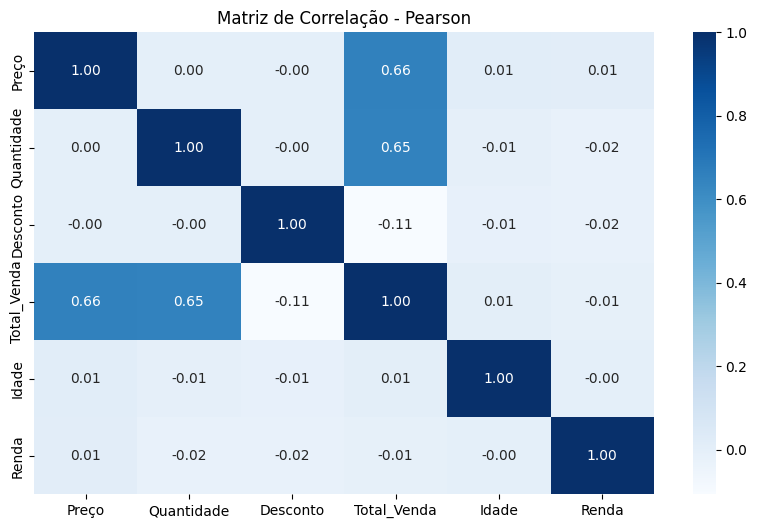

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_pearson, annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriz de Correlação - Pearson')
plt.show()


#### 1. Correlação entre Preço e Total_Venda (0.66)

Correlação moderada e positiva.

Quanto maior o preço do produto, maior tende a ser o valor total da venda.

Isso acontece porque produtos mais caros naturalmente elevam o ticket médio.

Relevância para o negócio
Produtos premium têm impacto direto no faturamento.



#### 2. Correlação entre Quantidade e Total_Venda (0.65)

Correlação moderada e positiva, quase igual à do preço.

Quanto maior a quantidade comprada, maior o valor total da venda.

Incentivar compras com quantidade maiores (ex.: combos, descontos progressivos) aumenta o faturamento.



## Estatística Inferencial

### 1. Promoções/descontos aumentam vendas?

Hipóteses:
H0: A quantidade média vendida é igual entre vendas com desconto (B) e sem desconto (A).

H1: A quantidade média da venda é diferente entre vendas com desconto (B) e sem desconto (A).

Nível de significância: α = 0,05



In [19]:
from scipy.stats import ttest_ind

grupo_A = df[df['Desconto'] == 0]['Quantidade']   
grupo_B = df[df['Desconto'] > 0]['Quantidade']      

stat, p = ttest_ind(grupo_A, grupo_B, equal_var=False)

print('Estatística t:', stat)
print('p-valor:', p)


Estatística t: 0.23723986033654434
p-valor: 0.8124781579102078


#### Interpetando: 
O p‑valor é 0,812, muito maior que 0,05.
Isso significa:

Não rejeitamos H0.  
Ou seja, não há diferença estatisticamente significativa na quantidade vendida entre vendas com desconto e sem desconto.

O valor t = 0,237 é extremamente baixo.
Isso indica que:

As médias dos dois grupos são praticamente iguais.
A diferença observada é tão pequena que pode ser explicada totalmente por variação aleatória.

Conclusão: O desconto NÃO aumentou a quantidade vendida.  

## 2. Black Friday vs Natal (vendas diárias na semana)


Hipóteses
H0: a média das vendas diárias na semana da Black Friday é igual à média das vendas diárias na semana do Natal.

H1: as médias são diferentes.

Nível de significância: α = 0,05

In [20]:
from scipy.stats import ttest_ind
import numpy as np


semana_black = df[(df['Data'] >= '2023-11-20') & (df['Data'] <= '2023-11-26')]
semana_natal = df[(df['Data'] >= '2023-12-18') & (df['Data'] <= '2023-12-24')]



bf_daily = semana_black .groupby('Data')['Total_Venda'].sum()
nat_daily = semana_natal.groupby('Data')['Total_Venda'].sum()

stat, p = ttest_ind(bf_daily, nat_daily, equal_var=False)

print('Estatística t:', stat)
print('p-valor:', p)


def ic_95(series):
    m = series.mean()
    s = series.std(ddof=1)
    n = len(series)
    erro = 1.96 * s / np.sqrt(n)
    return m - erro, m + erro

ic_bf = ic_95(bf_daily)
ic_nat = ic_95(nat_daily)

print('IC 95% BF:', ic_bf)
print('IC 95% Natal:', ic_nat)


Estatística t: -1.523939308895488
p-valor: 0.15580983801574416
IC 95% BF: (np.float64(9398.185999177276), np.float64(12445.265372251299))
IC 95% Natal: (np.float64(11276.90319400124), np.float64(13498.592120284477))


Inperpretando:

O p‑valor é 0,1558, maior que 0,05.

Não rejeitamos H0.  
Ou seja, não há diferença estatisticamente significativa entre as vendas diárias da Black Friday e do Natal

Conclusão: O teste A/B comparando as vendas diárias da semana da Black Friday com a semana do Natal não encontrou diferença estatisticamente significativa entre os períodos (t = –1,52; p = 0,156).
Os intervalos de confiança de 95% para as médias diárias das duas semanas se sobrepõem, indicando que a variação observada pode ser atribuída ao comportamento natural das vendas.
Conclui-se que o desempenho das duas semanas é estatisticamente equivalente, sem evidência de que uma tenha superado a outra de forma consistente.


## 3. Ticket médio geral e por faixa etária (IC 95%)

Hipóteses (para cada faixa, se quiser comparar)
H0: o ticket médio da faixa etária é igual ao ticket médio geral.

H1: o ticket médio da faixa etária é diferente do ticket médio geral.

Nível de significância: α = 0,05

In [21]:
import numpy as np

# ticket médio geral
tm_geral = df['Total_Venda']

def ic_95(series):
    m = series.mean()
    s = series.std(ddof=1)
    n = len(series)
    erro = 1.96 * s / np.sqrt(n)
    return m, m - erro, m + erro

ic_geral = ic_95(tm_geral)
print('Ticket médio geral e IC 95%:', ic_geral)

# por faixa etária (assumindo Faixa_Etaria já criada)
for faixa, grupo in df.groupby('Faixa_Etaria'):
    ic = ic_95(grupo['Total_Venda'])
    print(f'Faixa {faixa}: média e IC 95% = {ic}')


Ticket médio geral e IC 95%: (np.float64(245.90173583561645), np.float64(243.02752345604836), np.float64(248.77594821518454))
Faixa Jovem (0-25): média e IC 95% = (np.float64(239.25271993079585), np.float64(231.82852555584867), np.float64(246.67691430574303))
Faixa Adulto (26-40): média e IC 95% = (np.float64(246.78513686538463), np.float64(241.10732344362316), np.float64(252.4629502871461))
Faixa Meia-idade (41-60): média e IC 95% = (np.float64(247.72536164788733), np.float64(242.8692186159262), np.float64(252.58150467984845))
Faixa Idoso (60+): média e IC 95% = (np.float64(246.24446405322416), np.float64(240.42438062370135), np.float64(252.06454748274697))


C:\Users\luisg\AppData\Local\Temp\ipykernel_18140\3990682933.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for faixa, grupo in df.groupby('Faixa_Etaria'):


##### Ticket médio geral (IC 95%)
Média geral: R$ 245,09  
IC 95%: 243,03 a 248,78

Interpretação
O ticket médio geral da loja está estatisticamente entre R$ 243 e R$ 249.

O intervalo é estreito, indicando baixa variabilidade no comportamento de compra dos clientes.

Isso significa que, independentemente de idade, renda ou promoções, os clientes tendem a gastar valores muito próximos desse patamar.

Ticket médio por faixa etária


##### Faixa Jovem (0–25)
Média: R$ 239,25  
IC 95%: 231,83 a 246,67

Interpretação
É o grupo com menor ticket médio.

O intervalo é mais largo que o geral → jovens têm comportamento de compra mais variável.

Alguns gastam pouco, outros gastam mais, mas em média gastam menos que os demais grupos.

##### Faixa Adulto (26–40)
Média: R$ 246,76  
IC 95%: 241,10 a 252,46

Interpretação
Ticket médio muito próximo ao geral.

Intervalo relativamente estreito → comportamento de compra consistente.

É um grupo com padrão de gasto estável.

##### Faixa Meia‑idade (41–60)
Média: R$ 247,73  
IC 95%: 242,87 a 252,58

Interpretação
Ticket médio ligeiramente maior.

Intervalo estreito → clientes desse grupo têm padrão de compra bem definido.

É um dos grupos mais previsíveis.

##### Faixa Idoso (60+)
Média: R$ 246,44  
IC 95%: 240,44 a 252,06

Interpretação
Ticket médio praticamente igual ao dos adultos e meia‑idade.

Intervalo estreito → comportamento de compra estável.

Idosos gastam, em média, o mesmo que adultos e clientes de meia‑idade.

### 4. Black Friday vs mês anterior (média mensal)

Hipóteses
H0: a média de vendas no mês da Black Friday é igual à média de vendas no mês anterior.

H1: as médias são diferentes.

Nível de significância: α = 0,05

In [22]:
from scipy.stats import ttest_ind

# ajuste os meses conforme seu dataset
bf_month = df[(df['Data'].dt.month == 11)]
prev_month = df[(df['Data'].dt.month == 10)]

bf_daily = bf_month.groupby('Data')['Total_Venda'].sum()
prev_daily = prev_month.groupby('Data')['Total_Venda'].sum()

stat, p = ttest_ind(bf_daily, prev_daily, equal_var=False)

print('Estatística t:', stat)
print('p-valor:', p)


Estatística t: -1.0581476672127363
p-valor: 0.29441621030610104


Interpretação:

O p‑valor é 0,2944, muito maior que 0,05.
Não rejeitamos H0. Ou seja, não há diferença estatisticamente significativa entre as vendas diárias de novembro (mês da Black Friday) e outubro (mês anterior).

O valor t = –1,058 é baixo.
A diferença entre as médias dos dois meses é pequena e pode ser explicada totalmente por variação natural entre meses.


## Perguntas de negócio (equipe de marketing)

## 1. Quais foram as categorias produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas?

In [23]:
df.value_counts("Categoria")

Categoria
Alimentos Frescos              5475
Produtos de Mercearia          2190
Bebidas                        1825
Laticínios e Ovos              1825
Congelados                     1825
Pet Shop                       1825
Produtos de Higiene Pessoal    1825
Produtos de Limpeza            1825
Utilidades Domésticas          1460
Name: count, dtype: int64

In [24]:
agrupamento_categoria = df.groupby(['Categoria'])['Total_Venda'].sum().reset_index().sort_values('Total_Venda', ascending=False)

agrupamento_categoria


,Categoria,Total_Venda
0,Alimentos Frescos,"1,365,309.46"
7,Produtos de Mercearia,"529,653.65"
3,Laticínios e Ovos,"459,960.47"
1,Bebidas,"454,394.16"
6,Produtos de Limpeza,"447,545.86"
4,Pet Shop,"440,331.56"
5,Produtos de Higiene Pessoal,"440,039.48"
2,Congelados,"439,720.13"
8,Utilidades Domésticas,"359,522.58"


Considerando que, a partir da terceira categoria, os valores estarem próximos, vamos realizar a análise do pico de vendas das duas categorias mais vendidas.

In [25]:
CategoriaTop2 = agrupamento_categoria.head(2)
CategoriaTop2

,Categoria,Total_Venda
0,Alimentos Frescos,"1,365,309.46"
7,Produtos de Mercearia,"529,653.65"


In [26]:
filtro_top2 = df[(df['Categoria'] == 'Alimentos Frescos') | (df['Categoria'] == 'Produtos de Mercearia')].copy()


In [27]:
filtro_top2['Data'] = pd.to_datetime(filtro_top2['Data'])


In [28]:
filtro_top2['Mes'] = filtro_top2['Data'].dt.to_period('M').dt.to_timestamp()

In [29]:
vendas_mensais = (
    filtro_top2.groupby(['Categoria', 'Mes'])['Total_Venda']
    .sum()
    .reset_index().sort_values('Total_Venda',ascending=False)
)

vendas_mensais

,Categoria,Mes,Total_Venda
2,Alimentos Frescos,2023-03-01,"129,103.45"
6,Alimentos Frescos,2023-07-01,"126,769.38"
5,Alimentos Frescos,2023-06-01,"120,631.54"
9,Alimentos Frescos,2023-10-01,"116,440.75"
0,Alimentos Frescos,2023-01-01,"116,281.50"
7,Alimentos Frescos,2023-08-01,"114,280.75"
8,Alimentos Frescos,2023-09-01,"112,849.47"
11,Alimentos Frescos,2023-12-01,"111,652.58"
1,Alimentos Frescos,2023-02-01,"109,234.29"
10,Alimentos Frescos,2023-11-01,"105,294.10"


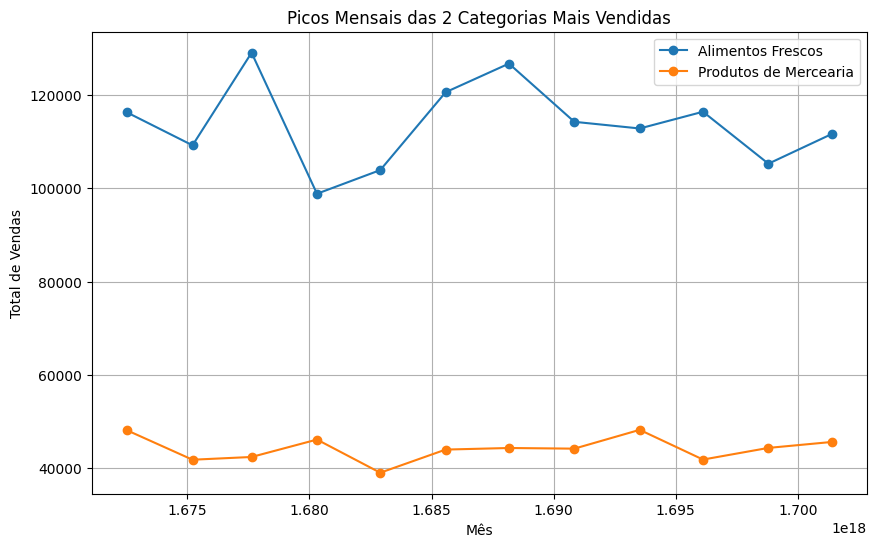

In [32]:
import matplotlib.pyplot as plt

vendas_mensais['Mes'] = vendas_mensais['Mes'].astype(int)
vendas_mensais = vendas_mensais.sort_values('Mes')


plt.figure(figsize=(10,6))

for categoria in filtro_top2['Categoria'].unique():
    dados = vendas_mensais[vendas_mensais['Categoria'] == categoria]
    plt.plot(dados['Mes'], dados['Total_Venda'], marker='o', label=categoria)

plt.title('Picos Mensais das 2 Categorias Mais Vendidas')
plt.xlabel('Mês')
plt.ylabel('Total de Vendas')
plt.legend()
plt.grid(True)



plt.show()

## 2. Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais produtos tiveram o maior aumento nas vendas durante as promoções? 

In [33]:
mascara_desconto = df['Desconto'] != 0
mascara_sem_desconto = df['Desconto'] == 0

In [34]:
df_desconto = df[mascara_desconto]
df_sem_desconto = df[mascara_sem_desconto]

In [35]:
media_Vendas_desconto = df_desconto['Total_Venda'].mean()
media_vendas_sem_desconto = df_sem_desconto['Total_Venda'].mean()

print(f'Media Vendas com desconto: {media_Vendas_desconto} \nMedia Vendas sem desconto: {media_vendas_sem_desconto}')



Media Vendas com desconto: 205.92529830143542 
Media Vendas sem desconto: 256.41457061969174


In [36]:
media_qtd_Vendas_desconto = df_desconto['Quantidade'].mean()
media_qtd_vendas_sem_desconto = df_sem_desconto['Quantidade'].mean()

print(f'Media quantidade Vendas com desconto: {media_qtd_Vendas_desconto} \nMedia quantidade Vendas sem desconto: {media_qtd_vendas_sem_desconto}')

Media quantidade Vendas com desconto: 9.989712918660286 
Media quantidade Vendas sem desconto: 10.012393834539163


As promoções reduziram o valor médio das vendas (ticket médio), mas não aumentaram de forma significativa a quantidade vendida.

In [37]:
QTD_vendas_promocao = df[mascara_desconto].groupby('Produto')['Quantidade'].mean()
QTD_vendas_sem_promocao = df[mascara_sem_desconto].groupby('Produto')['Quantidade'].mean()

impacto_produtos = (QTD_vendas_promocao - QTD_vendas_sem_promocao).sort_values(ascending=False)
impacto_produtos



Produto
Frango                                             1.39
Farinha                                            1.24
Bananas                                            1.00
Azeite                                             0.99
Talheres                                           0.96
Maçãs                                              0.87
Tilápia                                            0.78
Papel higiênico                                    0.75
Leite                                              0.64
Salmão                                             0.64
Feijão                                             0.55
Limpadores multiuso                                0.53
Cervejas                                           0.47
Ração para cães                                    0.46
Carne suína                                        0.45
Refrigerantes                                      0.30
Cenouras                                           0.28
Pratos prontos congelados               

frango, farinha e banana tiveram em média um aumento de uma unidade por compra com a promoção. Mas por ser um aumento relativamente pequeno, não podemos afirmar que a promoção impulsionou esse aumento.

## 3. Qual a média de vendas diárias por categoria de produto? 

In [38]:
media_diaria_categoria = (
    df.groupby(['Categoria', 'Data'])['Total_Venda'].sum()
      .groupby('Categoria').mean().sort_values(ascending=False)
)

media_diaria_categoria

Categoria
Alimentos Frescos             3,740.57
Produtos de Mercearia         1,451.11
Laticínios e Ovos             1,260.17
Bebidas                       1,244.92
Produtos de Limpeza           1,226.15
Pet Shop                      1,206.39
Produtos de Higiene Pessoal   1,205.59
Congelados                    1,204.71
Utilidades Domésticas           984.99
Name: Total_Venda, dtype: float64

## 4. Quais produtos apresentam a maior sazonalidade nas vendas (ex.: frutas e vegetais, sorvetes)? 

In [39]:
cv_produtos = (
    df.groupby(['Produto', 'Mes'])['Total_Venda']
      .sum()
      .groupby('Produto')
      .agg(['mean', 'std'])
)

cv_produtos['CV'] = cv_produtos['std'] / cv_produtos['mean']
cv_produtos = cv_produtos.sort_values('CV', ascending=False)
cv_produtos.head(10)

,mean,std,CV
Produto,,,
"Produtos descartáveis (pratos, copos, talheres)","7,208.36","1,662.65",0.23
Vinhos,"7,350.11","1,689.40",0.23
Sucos,"7,660.59","1,751.82",0.23
Atum,"7,702.52","1,734.46",0.23
Tomates,"7,649.39","1,708.07",0.22
Refrigerantes,"7,611.23","1,661.96",0.22
Croissants,"7,550.92","1,629.43",0.22
Ração para gatos,"7,229.33","1,494.00",0.21
Cervejas,"7,643.26","1,530.24",0.20


Bebidas (sucos, refrigerantes, cervejas, vinhos)
Esses produtos são altamente sazonais:

aumentam em meses quentes

aumentam em feriados e festas

caem em meses frios

produtos vegetais dependem a safra (alface, tomate)

## 5. Quais as faixas etárias contribuíram mais para as vendas totais? 


In [40]:
df['Faixa_Etaria'] = pd.cut(
    df['Idade'],
    bins=[18, 35, 59, 200],
    labels=['Jovem', 'Adulto', 'Idoso']
)

vendas_por_faixa = df.groupby('Faixa_Etaria')['Total_Venda'].sum().sort_values(ascending=False)
vendas_por_faixa



C:\Users\luisg\AppData\Local\Temp\ipykernel_18140\1131181550.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vendas_por_faixa = df.groupby('Faixa_Etaria')['Total_Venda'].sum().sort_values(ascending=False)


Faixa_Etaria
Adulto   2,102,041.77
Jovem    1,459,935.71
Idoso    1,297,252.20
Name: Total_Venda, dtype: float64

A faixa que maiscontribuiu foi a adulta (36 a 59)

## 6. Qual a distribuição das vendas ao longo dos dias da semana? 


In [41]:
df['Dia_Semana'] = df['Data'].dt.day_name(locale='pt_BR')



In [42]:
vendas_semana = (
    df.groupby('Dia_Semana')['Total_Venda']
      .sum()
      .sort_values(ascending=False)
)

vendas_semana


Dia_Semana
Domingo         722,783.68
Quarta-feira    710,052.02
Sábado          707,984.37
Sexta-feira     707,290.91
Quinta-feira    706,311.13
Segunda-feira   695,777.31
Terça-feira     686,277.94
Name: Total_Venda, dtype: float64

In [43]:
qtd_semana = (
    df.groupby('Dia_Semana')['Quantidade']
      .sum()
      .sort_values(ascending=False)
)

qtd_semana


Dia_Semana
Domingo          29398
Quarta-feira     29060
Sábado           28906
Sexta-feira      28724
Quinta-feira     28559
Segunda-feira    28313
Terça-feira      27944
Name: Quantidade, dtype: int64

começo da semana são dias mais fracos (segunda e terça). Domingo é o dia de mais vendas, indicando forte movimento em finais de semanas

## 7. Como as vendas mensais se comparam antes e durante a Black Friday? 


In [44]:
df['Mes_numeral'] = df['Data'].dt.month

vendas_mensais = df.groupby('Mes_numeral')['Total_Venda'].sum()
vendas_mensais


Mes_numeral
1    436,669.71
2    400,993.07
3    434,595.18
4    389,706.57
5    381,634.96
6    419,441.55
7    449,736.77
8    402,805.95
9    406,676.58
10   416,884.85
11   385,743.38
12   411,588.78
Name: Total_Venda, dtype: float64

In [45]:
antes = vendas_mensais[vendas_mensais.index < 11].mean()
durante = vendas_mensais.loc[11]

print(f'média de vendas nos meses anteriores a blackfriday {antes} \nVendas no mês da blackfriday {durante}')

média de vendas nos meses anteriores a blackfriday 413914.51897000003 
Vendas no mês da blackfriday 385743.3809


Conforme demonstrado, não houve aumento de vendas no mês da blackfriday, inclusive ocorreu uma diminuição na valor de venda em novembro.

## 8. Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias de produto?

In [46]:
ticket_faixa = df.groupby('Faixa_Etaria')['Total_Venda'].mean().sort_values(ascending=False)
ticket_faixa


C:\Users\luisg\AppData\Local\Temp\ipykernel_18140\2534847288.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ticket_faixa = df.groupby('Faixa_Etaria')['Total_Venda'].mean().sort_values(ascending=False)


Faixa_Etaria
Adulto   247.79
Idoso    247.33
Jovem    242.64
Name: Total_Venda, dtype: float64

In [47]:
tabela_faixa_categoria = (
    df.groupby(['Faixa_Etaria', 'Categoria'])['Total_Venda']
      .mean()
      .reset_index()
      .sort_values(['Faixa_Etaria', 'Total_Venda'], ascending=[True, False])
)

tabela_faixa_categoria


C:\Users\luisg\AppData\Local\Temp\ipykernel_18140\3619751258.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Faixa_Etaria', 'Categoria'])['Total_Venda']


,Faixa_Etaria,Categoria,Total_Venda
3,Jovem,Laticínios e Ovos,253.35
1,Jovem,Bebidas,249.02
6,Jovem,Produtos de Limpeza,248.85
8,Jovem,Utilidades Domésticas,246.28
0,Jovem,Alimentos Frescos,241.87
7,Jovem,Produtos de Mercearia,238.48
4,Jovem,Pet Shop,237.59
5,Jovem,Produtos de Higiene Pessoal,236.28
2,Jovem,Congelados,235.10
9,Adulto,Alimentos Frescos,253.66


O jovem tem um ticket médio moderado, mas compra categorias de conveniência e uso rápido: bebidas, limpeza, utilidades domésticas

O adulto é o grupo com maior poder de compra e maior consistência.
Ele compra categorias essenciais (alimentos frescos, limpeza, laticínios) e também categorias de maior valor agregado (pet shop, utilidades).

Ele compra mais itens de consumo básico (laticínios, alimentos frescos), mas também tem ticket alto em bebidas e utilidades domésticas.

## 9. Qual é a relação entre a idade dos clientes e o valor total das compras?

In [48]:
df[['Idade', 'Total_Venda']].corr()


,Idade,Total_Venda
Idade,1.00,0.01
Total_Venda,0.01,1.00


A análise da correlação entre idade e valor total das compras mostra que não há relação linear entre essas variáveis. O coeficiente de correlação encontrado (0,01) indica que a idade dos clientes não influencia o valor gasto por transação.

Embora análises por faixa etária mostrem diferenças médias entre grupos (jovens, adultos e idosos), essas diferenças não se mantêm quando avaliamos a idade individual. Assim, o comportamento de compra é mais determinado por fatores como categoria de produto, frequência de compra e contexto da transação do que pela idade do cliente

In [49]:
total_por_idade = (
    df.groupby('Idade')['Total_Venda']
      .mean()
      .sort_values(ascending=False)
)

total_por_idade


Idade
67   272.06
33   270.09
45   268.61
68   267.13
69   263.81
26   263.53
60   262.08
63   259.66
37   259.24
52   258.94
22   256.92
58   254.85
49   254.78
36   253.48
50   253.26
40   252.35
41   251.66
30   250.94
47   249.19
54   249.08
21   248.64
53   248.35
20   248.03
71   248.00
51   247.81
56   247.67
46   246.32
38   246.25
29   244.13
44   243.91
39   243.52
43   243.16
65   242.83
72   242.29
35   242.02
61   241.96
57   240.28
66   240.18
64   239.77
59   239.38
74   238.08
32   238.08
27   237.73
23   236.61
28   236.40
19   235.05
18   234.08
42   234.00
34   233.55
73   232.81
48   232.02
31   230.52
55   230.50
62   229.93
70   229.13
25   228.74
24   225.66
Name: Total_Venda, dtype: float64

## 10. comparando a semana da "Black Friday" com a do Natal, qual semana a empresa teve melhores desempenhos em relação à média de vendas? 

In [50]:
df['Semana'] = df['Data'].dt.isocalendar().week

df['Semana'].unique()



<IntegerArray>
[52,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Length: 52, dtype: UInt32

In [51]:
import datetime as dt

print(f'Semana da blackfriday: {dt.date(2023, 11, 24).isocalendar().week} \nSemana do natal: {dt.date(2023, 12, 25).isocalendar().week
}')


Semana da blackfriday: 47 
Semana do natal: 52


In [52]:
semana_black = df[df['Semana'] == 47]
semana_natal = df[df['Semana'] == 52]


In [53]:
media_black = semana_black['Total_Venda'].mean()
media_natal = semana_natal['Total_Venda'].mean()
qtd_black = semana_black['Quantidade'].sum()
qtd_natal = semana_natal['Quantidade'].sum()

print(f'Média blackfriday: {media_black} \nMéda Natal: {media_natal} \nQuantidade Black: {qtd_black} \nQuantidade natal {qtd_natal}')



Média blackfriday: 198.57683064935065 
Méda Natal: 219.74641522727276 
Quantidade Black: 3733 
Quantidade natal 4545


Em média, cada venda na semana do Natal foi mais cara

A semana do Natal teve 812 itens a mais vendidos.
Isso é um aumento de 21,7% no volume.